# Embeddings & Similarity Analysis

**Paper 2: Cross-Code Comparative Analysis - Part 7**

This notebook explores semantic embeddings for legal article analysis:

1. **Embedding Generation**: Compare different embedding models (ruBERT, E5, BGE-M3)
2. **Visualization**: UMAP/t-SNE projections to visualize code clusters
3. **Clustering**: HDBSCAN to discover article groupings
4. **Cross-Code Similarity**: Find semantically similar articles across different codes

**Goal**: Move beyond bag-of-words (TF-IDF) to semantic representations that capture meaning.

## 1. Setup and Imports

In [73]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Embeddings
from sentence_transformers import SentenceTransformer

# Dimensionality reduction
import umap
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Clustering
import hdbscan
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Similarity
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

# Create output directory
OUTPUT_DIR = Path("../output/07")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete!")

Setup complete!


## 2. Data Loading

In [75]:
CODES = {
    "criminal": {
        "history_folder": "K1400000226_rus_ugolov",
        "name_en": "Criminal Code",
        "short": "УК",
        "color": "#e74c3c"  # red
    },
    "administrative": {
        "history_folder": "K1400000235_rus_adm",
        "name_en": "Administrative Code",
        "short": "КоАП",
        "color": "#3498db"  # blue
    },
    "civil": {
        "history_folder": "K940001000__rus_grazh",
        "name_en": "Civil Code",
        "short": "ГК",
        "color": "#2ecc71"  # green
    },
    "labor": {
        "history_folder": "K1500000414_rus_trud",
        "name_en": "Labor Code",
        "short": "ТК",
        "color": "#f39c12"  # orange
    },
    "tax": {
        "history_folder": "K2500000214_rus_nalog",
        "name_en": "Tax Code",
        "short": "НК",
        "color": "#9b59b6"  # purple
    }
}

DATA_PATH = Path("../data/raw/by_history")

def load_latest_version(history_folder):
    """Load the latest version of a legal code from historical data."""
    folder_path = DATA_PATH / history_folder
    index_path = folder_path / "versions_index.json"
    
    with open(index_path, "r", encoding="utf-8") as f:
        index = json.load(f)
    
    latest_version = index["versions"][-1]
    version_file = folder_path / latest_version["filename"]
    
    with open(version_file, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    return data["articles"], latest_version

import re

def is_excluded_article(text):
    """
    Detect articles that only contain a footnote about being excluded.
    These articles have text like: "Сноска. Статью XXX исключена Законом РК от..."
    """
    if not text:
        return True
    
    text_clean = text.strip()
    
    # Pattern for excluded articles: starts with "Сноска." and contains "исключена"
    excluded_pattern = r'^Сноска\.\s*Стать[юя]\s+[\d\-]+\s+исключена'
    
    if re.match(excluded_pattern, text_clean, re.IGNORECASE):
        return True
    
    return False

# Load all codes into a single DataFrame
all_articles = []
excluded_count = 0

for code_key, code_info in CODES.items():
    articles, version_info = load_latest_version(code_info["history_folder"])
    
    for article in articles:
        text = article.get("article_text", "")
        
        # Skip very short articles
        if not text or len(text.split()) <= 10:
            continue
        
        # Skip excluded articles (only contain "Сноска. Статья ... исключена")
        if is_excluded_article(text):
            excluded_count += 1
            continue
            
        all_articles.append({
            "code_key": code_key,
            "code_short": code_info["short"],
            "code_name": code_info["name_en"],
            "code_color": code_info["color"],
            "article_id": article.get("article_id", ""),
            "article_title": article.get("article_title", ""),
            "text": text,
            "section": article.get("section", ""),
            "chapter": article.get("chapter", ""),
            "paragraphs": article.get("paragraphs", [])
        })
    
    print(f"{code_info['short']}: {len([a for a in all_articles if a['code_key'] == code_key])} articles (version: {version_info['version_date']})")

df = pd.DataFrame(all_articles)
print(f"\nTotal articles: {len(df)}")
print(f"Excluded articles (only contain 'исключена' footnote): {excluded_count}")
print(f"\nClass distribution:")
print(df['code_short'].value_counts())

УК: 489 articles (version: 16.09.2025)
КоАП: 1009 articles (version: 17.12.2025)
ГК: 410 articles (version: 20.11.2025)
ТК: 218 articles (version: 16.09.2025)
НК: 838 articles (version: 18.07.2025)

Total articles: 2964
Excluded articles (only contain 'исключена' footnote): 0

Class distribution:
code_short
КоАП    1009
НК       838
УК       489
ГК       410
ТК       218
Name: count, dtype: int64


## 3. Embedding Models Comparison

We'll compare several embedding models:

| Model | Description | Dimension |
|-------|-------------|----------|
| `intfloat/multilingual-e5-base` | Multilingual E5, good for Russian | 768 |
| `BAAI/bge-m3` | BGE-M3, state-of-the-art multilingual | 1024 |
| `cointegrated/rubert-tiny2` | Small Russian BERT, fast | 312 |
| `ai-forever/sbert_large_nlu_ru` | Russian SBERT, semantic similarity | 1024 |

In [76]:
# Define embedding models to compare
EMBEDDING_MODELS = {
    "e5-multilingual": "intfloat/multilingual-e5-base",
    "rubert-tiny": "cointegrated/rubert-tiny2",
    "sbert-ru": "ai-forever/sbert_large_nlu_ru",
}

# For E5 models, we need to add "query: " prefix
E5_MODELS = ["e5-multilingual"]

print("Available embedding models:")
for name, model_id in EMBEDDING_MODELS.items():
    print(f"  - {name}: {model_id}")

Available embedding models:
  - e5-multilingual: intfloat/multilingual-e5-base
  - rubert-tiny: cointegrated/rubert-tiny2
  - sbert-ru: ai-forever/sbert_large_nlu_ru


In [77]:
def generate_embeddings(texts, model_name, model_id, batch_size=32):
    """Generate embeddings for a list of texts."""
    print(f"Loading model: {model_id}...")
    model = SentenceTransformer(model_id)
    
    # Add prefix for E5 models
    if model_name in E5_MODELS:
        texts = [f"query: {t}" for t in texts]
    
    print(f"Generating embeddings for {len(texts)} texts...")
    embeddings = model.encode(
        texts, 
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True
    )
    
    print(f"Embedding shape: {embeddings.shape}")
    return embeddings

In [78]:
# Prepare texts - use first 500 chars to avoid token limit issues
MAX_TEXT_LENGTH = 512
texts = df['text'].apply(lambda x: x[:MAX_TEXT_LENGTH]).tolist()

print(f"Prepared {len(texts)} texts for embedding")
print(f"Sample text (truncated): {texts[0][:100]}...")

Prepared 2964 texts for embedding
Sample text (truncated): 1. Уголовное законодательство Республики Казахстан состоит из настоящего Уголовного кодекса Республи...


In [79]:
# Generate embeddings with primary model (E5 multilingual)
# This is our main model - others can be compared later

PRIMARY_MODEL = "e5-multilingual"
embeddings = generate_embeddings(
    texts, 
    PRIMARY_MODEL, 
    EMBEDDING_MODELS[PRIMARY_MODEL]
)

# Save embeddings
np.save(OUTPUT_DIR / f"embeddings_{PRIMARY_MODEL}.npy", embeddings)
print(f"\nSaved embeddings to output/07/embeddings_{PRIMARY_MODEL}.npy")

Loading model: intfloat/multilingual-e5-base...
Generating embeddings for 2964 texts...


Batches:   0%|          | 0/93 [00:00<?, ?it/s]

Embedding shape: (2964, 768)

Saved embeddings to output/07/embeddings_e5-multilingual.npy


## 4. Dimensionality Reduction & Visualization

### 4.1 UMAP Projection

In [80]:
# UMAP reduction to 2D
print("Running UMAP dimensionality reduction...")

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='cosine',
    random_state=42
)

embeddings_2d = reducer.fit_transform(embeddings)

# Add to dataframe
df['umap_x'] = embeddings_2d[:, 0]
df['umap_y'] = embeddings_2d[:, 1]

print(f"UMAP complete. Shape: {embeddings_2d.shape}")

Running UMAP dimensionality reduction...
UMAP complete. Shape: (2964, 2)


In [81]:
df.head(3)

,code_key,code_short,code_name,code_color,article_id,article_title,text,section,chapter,paragraphs,umap_x,umap_y
0,criminal,УК,Criminal Code,#e74c3c,z2,Статья 1. Уголовное законодательство Республик...,1. Уголовное законодательство Республики Казах...,None,None,"[{'id': 'z3', 'number': '1', 'text': 'Уголовно...",6.637551,6.324727
1,criminal,УК,Criminal Code,#e74c3c,z6,Статья 2. Задачи Уголовного кодекса,1. Задачами настоящего Кодекса являются: защит...,None,None,"[{'id': 'z8', 'number': '1', 'text': 'Задачами...",6.767651,6.113688
2,criminal,УК,Criminal Code,#e74c3c,z3002,"Статья 3. Разъяснение некоторых понятий, содер...",Содержащиеся в настоящем Кодексе понятия имеют...,None,None,"[{'id': 'z3002-p1', 'number': None, 'text': 'С...",9.836865,8.719158


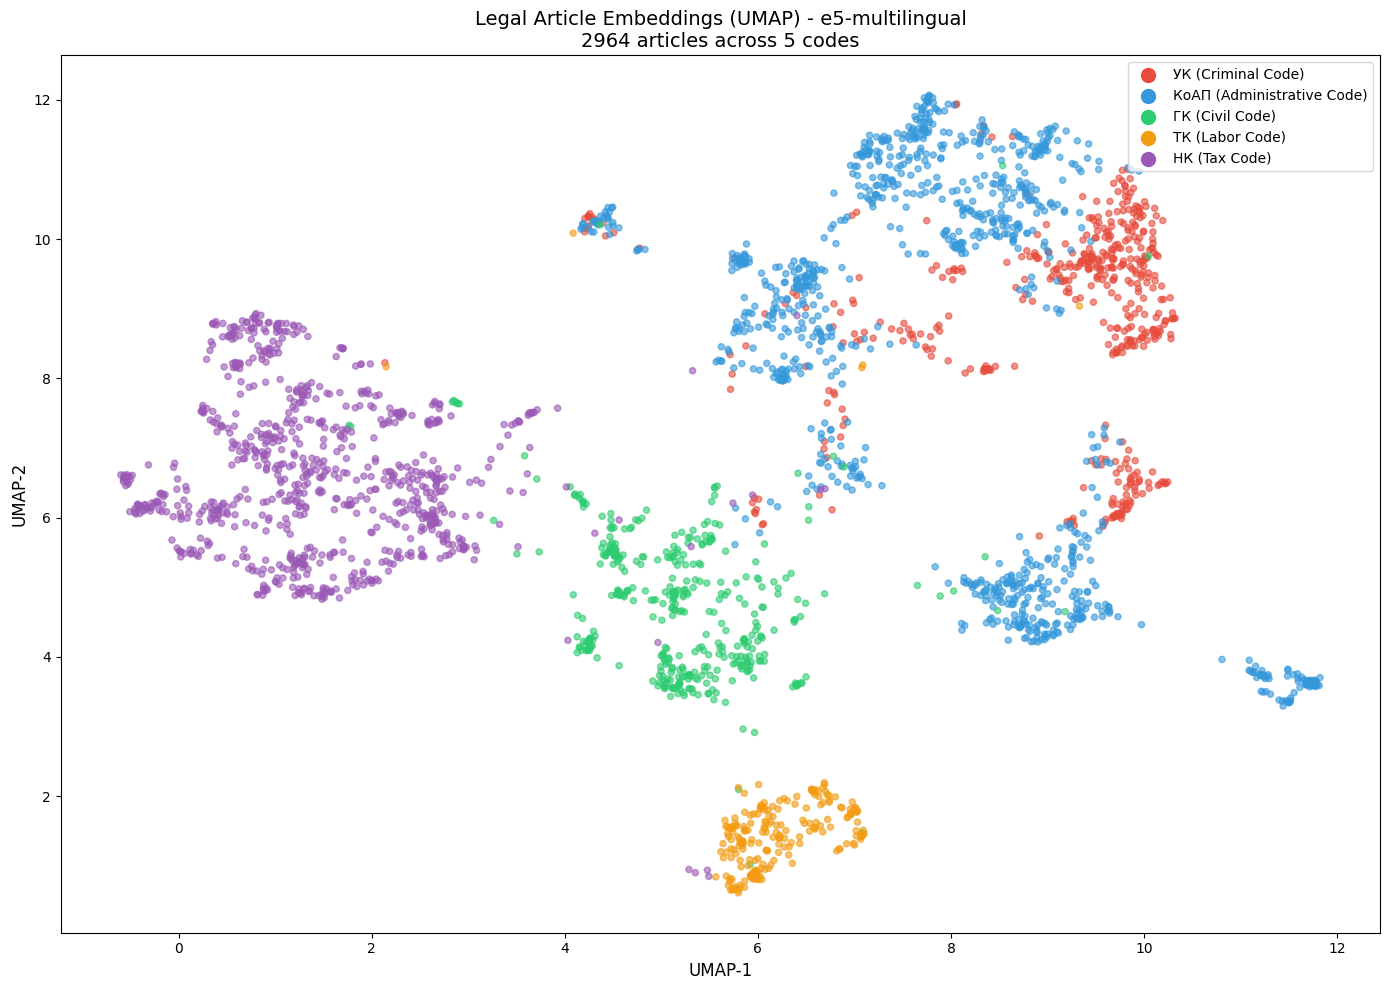

In [82]:
# Static visualization with matplotlib
fig, ax = plt.subplots(figsize=(14, 10))

# Color map
colors = [CODES[code_key]['color'] for code_key in df['code_key']]

scatter = ax.scatter(
    df['umap_x'], 
    df['umap_y'], 
    c=colors,
    alpha=0.6,
    s=20
)

# Legend
legend_elements = [
    plt.scatter([], [], c=info['color'], label=f"{info['short']} ({info['name_en']})", s=100)
    for info in CODES.values()
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

ax.set_xlabel('UMAP-1', fontsize=12)
ax.set_ylabel('UMAP-2', fontsize=12)
ax.set_title(f'Legal Article Embeddings (UMAP) - {PRIMARY_MODEL}\n{len(df)} articles across 5 codes', fontsize=14)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "umap_visualization.png", dpi=150, bbox_inches='tight')
plt.show()

In [84]:
# Interactive visualization with Plotly
fig = px.scatter(
    df, 
    x='umap_x', 
    y='umap_y',
    color='code_short',
    color_discrete_map={info['short']: info['color'] for info in CODES.values()},
    hover_data=['article_title', 'chapter'],
    title=f'Legal Article Embeddings (UMAP) - Interactive',
    labels={'umap_x': 'UMAP-1', 'umap_y': 'UMAP-2', 'code_short': 'Code'}
)

fig.update_traces(marker=dict(size=6, opacity=0.7))
fig.update_layout(width=1000, height=700)
fig.write_html(OUTPUT_DIR / "umap_interactive.html")
# fig.show()

### 4.2 t-SNE Projection (for comparison)

In [85]:
# t-SNE for comparison (slower but sometimes better local structure)
print("Running t-SNE dimensionality reduction...")

# First reduce with PCA to speed up t-SNE
pca = PCA(n_components=50, random_state=42)
embeddings_pca = pca.fit_transform(embeddings)
print(f"PCA variance explained: {pca.explained_variance_ratio_.sum():.2%}")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    max_iter=1000
)

embeddings_tsne = tsne.fit_transform(embeddings_pca)

df['tsne_x'] = embeddings_tsne[:, 0]
df['tsne_y'] = embeddings_tsne[:, 1]

print(f"t-SNE complete. Shape: {embeddings_tsne.shape}")

Running t-SNE dimensionality reduction...
PCA variance explained: 57.92%
t-SNE complete. Shape: (2964, 2)


In [ ]:
# Compare UMAP and t-SNE side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

colors = [CODES[code_key]['color'] for code_key in df['code_key']]

# UMAP
axes[0].scatter(df['umap_x'], df['umap_y'], c=colors, alpha=0.6, s=15)
axes[0].set_xlabel('UMAP-1', fontsize=11)
axes[0].set_ylabel('UMAP-2', fontsize=11)
axes[0].set_title('UMAP Projection', fontsize=13)

# t-SNE
axes[1].scatter(df['tsne_x'], df['tsne_y'], c=colors, alpha=0.6, s=15)
axes[1].set_xlabel('t-SNE-1', fontsize=11)
axes[1].set_ylabel('t-SNE-2', fontsize=11)
axes[1].set_title('t-SNE Projection', fontsize=13)

# Shared legend
legend_elements = [
    plt.scatter([], [], c=info['color'], label=f"{info['short']}", s=100)
    for info in CODES.values()
]
fig.legend(handles=legend_elements, loc='center right', fontsize=10, bbox_to_anchor=(1.02, 0.5))

plt.suptitle(f'Embedding Visualization Comparison - {len(df)} Articles', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "umap_vs_tsne.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Clustering Analysis

### 5.1 HDBSCAN Clustering

In [89]:
# HDBSCAN clustering on full embeddings
print("Running HDBSCAN clustering...")

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=60,
    min_samples=5,
    metric='euclidean',
    cluster_selection_method='eom'
)

# Use UMAP embeddings for clustering (better than raw high-dim)
cluster_labels = clusterer.fit_predict(embeddings_2d)

df['cluster'] = cluster_labels

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = (cluster_labels == -1).sum()

print(f"\nHDBSCAN Results:")
print(f"  Clusters found: {n_clusters}")
print(f"  Noise points: {n_noise} ({n_noise/len(df)*100:.1f}%)")
print(f"\nCluster sizes:")
print(pd.Series(cluster_labels).value_counts().head(15))

Running HDBSCAN clustering...

HDBSCAN Results:
  Clusters found: 12
  Noise points: 343 (11.6%)

Cluster sizes:
 3     716
-1     343
 4     329
 1     322
 2     220
 11    190
 6     180
 10    141
 7     139
 9     130
 5     100
 8      78
 0      76
Name: count, dtype: int64


In [90]:
# Analyze cluster composition by legal code
print("\nCluster Composition by Legal Code:")
print("="*60)

cluster_composition = pd.crosstab(
    df['cluster'], 
    df['code_short'], 
    normalize='index'
) * 100

# Show top clusters (excluding noise)
top_clusters = df[df['cluster'] != -1]['cluster'].value_counts().head(10).index

for cluster_id in top_clusters:
    cluster_data = df[df['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} ({len(cluster_data)} articles):")
    
    # Code distribution
    code_dist = cluster_data['code_short'].value_counts()
    dominant_code = code_dist.index[0]
    purity = code_dist.iloc[0] / len(cluster_data) * 100
    
    print(f"  Dominant: {dominant_code} ({purity:.1f}%)")
    print(f"  Composition: {dict(code_dist)}")
    
    # Sample titles
    print(f"  Sample articles:")
    for _, row in cluster_data.head(3).iterrows():
        title = row['article_title'][:60]
        print(f"    - [{row['code_short']}] {title}...")


Cluster Composition by Legal Code:

Cluster 3 (716 articles):
  Dominant: КоАП (56.3%)
  Composition: {'КоАП': np.int64(403), 'УК': np.int64(310), 'ГК': np.int64(2), 'ТК': np.int64(1)}
  Sample articles:
    - [УК] Статья 3. Разъяснение некоторых понятий, содержащихся в наст...
    - [УК] Статья 43. Привлечение к общественным работам...
    - [УК] Статья 44. Ограничение свободы...

Cluster 4 (329 articles):
  Dominant: КоАП (76.3%)
  Composition: {'КоАП': np.int64(251), 'УК': np.int64(69), 'ГК': np.int64(4), 'НК': np.int64(3), 'ТК': np.int64(2)}
  Sample articles:
    - [УК] Статья 1. Уголовное законодательство Республики Казахстан...
    - [УК] Статья 2. Задачи Уголовного кодекса...
    - [УК] Статья 7. Действие уголовного закона в отношении лиц, соверш...

Cluster 1 (322 articles):
  Dominant: КоАП (73.0%)
  Composition: {'КоАП': np.int64(235), 'УК': np.int64(81), 'ГК': np.int64(6)}
  Sample articles:
    - [УК] Статья 4. Основание уголовной ответственности...
    - [УК] Статья 5. Д

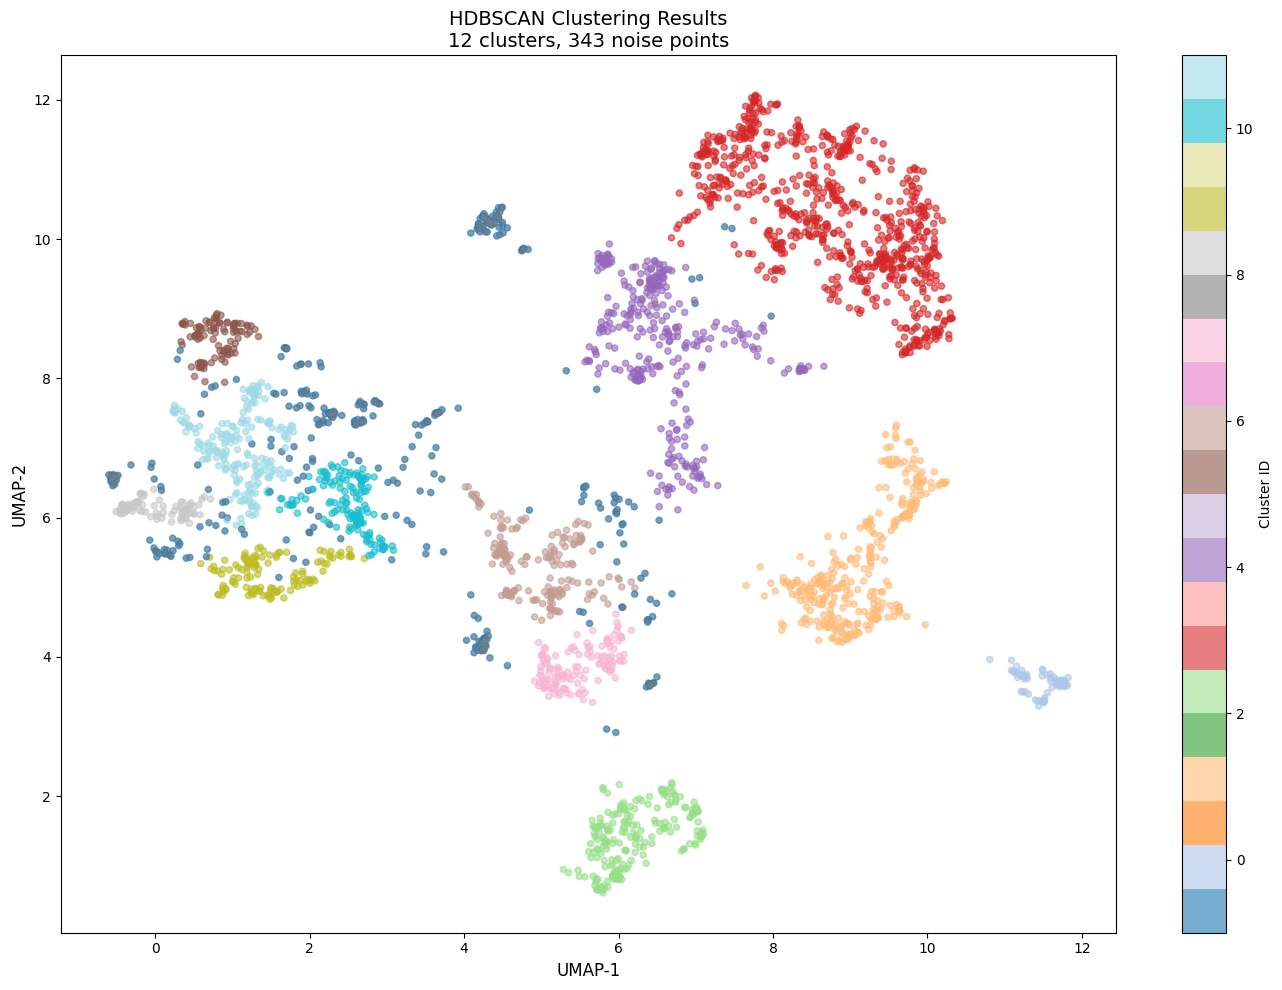

In [91]:
# Visualize clusters
fig, ax = plt.subplots(figsize=(14, 10))

# Color by cluster
scatter = ax.scatter(
    df['umap_x'], 
    df['umap_y'], 
    c=df['cluster'],
    cmap='tab20',
    alpha=0.6,
    s=20
)

# Mark noise points
noise_mask = df['cluster'] == -1
ax.scatter(
    df.loc[noise_mask, 'umap_x'],
    df.loc[noise_mask, 'umap_y'],
    c='gray',
    alpha=0.3,
    s=10,
    label='Noise'
)

plt.colorbar(scatter, label='Cluster ID')
ax.set_xlabel('UMAP-1', fontsize=12)
ax.set_ylabel('UMAP-2', fontsize=12)
ax.set_title(f'HDBSCAN Clustering Results\n{n_clusters} clusters, {n_noise} noise points', fontsize=14)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "hdbscan_clusters.png", dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Cluster Quality Metrics

In [92]:
# Calculate clustering quality metrics
# Remove noise points for metrics
valid_mask = df['cluster'] != -1

if valid_mask.sum() > 100:
    # Silhouette score (internal metric)
    silhouette = silhouette_score(
        embeddings_2d[valid_mask], 
        df.loc[valid_mask, 'cluster']
    )
    
    # Adjusted Rand Index vs actual legal codes (external metric)
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    true_labels = le.fit_transform(df.loc[valid_mask, 'code_short'])
    ari = adjusted_rand_score(true_labels, df.loc[valid_mask, 'cluster'])
    
    print("Clustering Quality Metrics:")
    print("="*50)
    print(f"Silhouette Score: {silhouette:.4f}")
    print(f"  (Range: -1 to 1, higher is better)")
    print(f"\nAdjusted Rand Index vs Legal Codes: {ari:.4f}")
    print(f"  (Range: -0.5 to 1, 1 = perfect match with codes)")
    
    # Cluster purity
    purity_scores = []
    for cluster_id in df.loc[valid_mask, 'cluster'].unique():
        cluster_codes = df.loc[df['cluster'] == cluster_id, 'code_short']
        purity = cluster_codes.value_counts().iloc[0] / len(cluster_codes)
        purity_scores.append(purity)
    
    avg_purity = np.mean(purity_scores)
    print(f"\nAverage Cluster Purity: {avg_purity:.4f}")
    print(f"  (1.0 = each cluster contains only one code)")
else:
    print("Not enough non-noise points for quality metrics")

Clustering Quality Metrics:
Silhouette Score: 0.5452
  (Range: -1 to 1, higher is better)

Adjusted Rand Index vs Legal Codes: 0.3177
  (Range: -0.5 to 1, 1 = perfect match with codes)

Average Cluster Purity: 0.9153
  (1.0 = each cluster contains only one code)


## 6. Cross-Code Similarity Analysis

Find articles from different codes that are semantically similar.

In [93]:
# Compute pairwise cosine similarity
print("Computing cosine similarity matrix...")
similarity_matrix = cosine_similarity(embeddings)
print(f"Similarity matrix shape: {similarity_matrix.shape}")

Computing cosine similarity matrix...
Similarity matrix shape: (2964, 2964)


In [94]:
def find_cross_code_similar(df, similarity_matrix, source_code, target_code, top_k=10):
    """Find most similar articles between two different codes."""
    
    source_mask = df['code_short'] == source_code
    target_mask = df['code_short'] == target_code
    
    source_indices = df[source_mask].index.tolist()
    target_indices = df[target_mask].index.tolist()
    
    # Get similarity submatrix
    sub_sim = similarity_matrix[np.ix_(source_indices, target_indices)]
    
    # Find top pairs
    pairs = []
    for i, src_idx in enumerate(source_indices):
        for j, tgt_idx in enumerate(target_indices):
            pairs.append({
                'source_idx': src_idx,
                'target_idx': tgt_idx,
                'similarity': sub_sim[i, j]
            })
    
    # Sort by similarity
    pairs_df = pd.DataFrame(pairs).sort_values('similarity', ascending=False).head(top_k)
    
    return pairs_df

In [97]:
# Find similar articles between УК (Criminal) and КоАП (Administrative)
# These codes both deal with offenses but at different severity levels
print("Cross-Code Similarity: УК (Criminal) ↔ КоАП (Administrative)")
print("="*70)
print("\nThese codes both deal with offenses - finding overlapping topics...\n")

uk_koap_pairs = find_cross_code_similar(df, similarity_matrix, 'УК', 'КоАП', top_k=10)

for _, row in uk_koap_pairs.iterrows():
    src = df.loc[row['source_idx']]
    tgt = df.loc[row['target_idx']]
    
    print(f"Similarity: {row['similarity']:.4f}")
    print(f"  [УК]   {src['article_title'][:100]}...")
    print(f"  [КоАП] {tgt['article_title'][:100]}...")
    print()

Cross-Code Similarity: УК (Criminal) ↔ КоАП (Administrative)

These codes both deal with offenses - finding overlapping topics...

Similarity: 0.9885
  [УК]   Статья 237. Неправомерные действия при реабилитации и банкротстве...
  [КоАП] Статья 176. Неправомерные действия при реабилитации и банкротстве юридических лиц и индивидуальных п...

Similarity: 0.9831
  [УК]   Статья 239. Доведение до неплатежеспособности...
  [КоАП] Статья 176. Неправомерные действия при реабилитации и банкротстве юридических лиц и индивидуальных п...

Similarity: 0.9816
  [УК]   Статья 34. Крайняя необходимость...
  [КоАП] Статья 37. Крайняя необходимость...

Similarity: 0.9801
  [УК]   Статья 340. Незаконная порубка, уничтожение или повреждение деревьев и кустарников...
  [КоАП] Статья 381-1. Незаконная порубка, уничтожение или повреждение деревьев и кустарников...

Similarity: 0.9766
  [УК]   Статья 7. Действие уголовного закона в отношении лиц, совершивших уголовное правонарушение на террит...
  [КоАП] Стат

In [98]:
# Find similar articles between ГК (Civil) and ТК (Labor)
print("Cross-Code Similarity: ГК (Civil) ↔ ТК (Labor)")
print("="*70)
print("\nCivil and Labor codes may share contract/obligation concepts...\n")

gk_tk_pairs = find_cross_code_similar(df, similarity_matrix, 'ГК', 'ТК', top_k=10)

for _, row in gk_tk_pairs.iterrows():
    src = df.loc[row['source_idx']]
    tgt = df.loc[row['target_idx']]
    
    print(f"Similarity: {row['similarity']:.4f}")
    print(f"  [ГК] {src['article_title'][:70]}...")
    print(f"  [ТК] {tgt['article_title'][:70]}...")
    print()

Cross-Code Similarity: ГК (Civil) ↔ ТК (Labor)

Civil and Labor codes may share contract/obligation concepts...

Similarity: 0.9403
  [ГК] Статья 172. Определение срока...
  [ТК] Статья 13. Исчисление сроков, установленных настоящим Кодексом...

Similarity: 0.9333
  [ГК] Статья 3. Гражданское законодательство Республики Казахстан...
  [ТК] Статья 2. Трудовое законодательство Республики Казахстан...

Similarity: 0.9323
  [ГК] Статья 110. Объединение индивидуальных предпринимателей и (или) юридич...
  [ТК] Статья 20-1. Объединения (ассоциации, союзы) работодателей и их полном...

Similarity: 0.9206
  [ГК] Статья 402. Порядок изменения и расторжения договора...
  [ТК] Статья 50. Порядок расторжения трудового договора по соглашению сторон...

Similarity: 0.9204
  [ГК] Статья 386. Действие договора...
  [ТК] Статья 158. Сроки, сфера действия коллективного договора и ответственн...

Similarity: 0.9193
  [ГК] Статья 403. Последствия расторжения и изменения договора...
  [ТК] Статья 158. Сроки

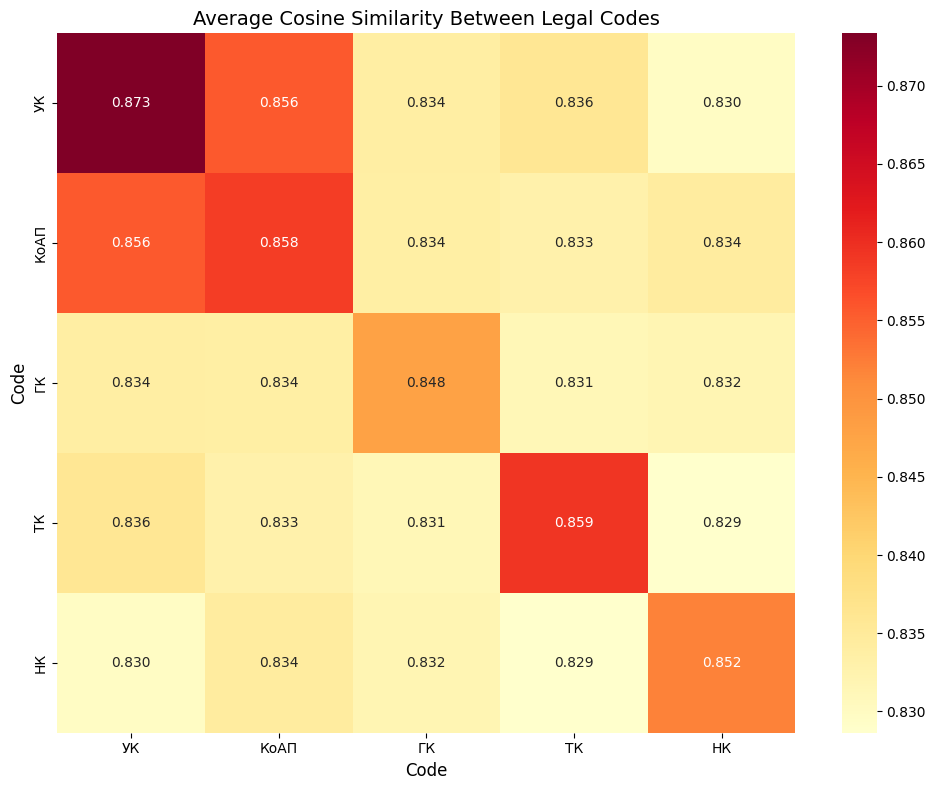


Interpretation:
- Higher values indicate codes share more semantic content
- Diagonal shows within-code similarity (excluding self)


In [99]:
# Create cross-code similarity heatmap (average similarity between codes)
codes_list = list(CODES.keys())
code_shorts = [CODES[c]['short'] for c in codes_list]

avg_similarities = np.zeros((5, 5))

for i, code1 in enumerate(code_shorts):
    for j, code2 in enumerate(code_shorts):
        mask1 = df['code_short'] == code1
        mask2 = df['code_short'] == code2
        
        idx1 = df[mask1].index.tolist()
        idx2 = df[mask2].index.tolist()
        
        sub_sim = similarity_matrix[np.ix_(idx1, idx2)]
        
        if i != j:
            avg_similarities[i, j] = sub_sim.mean()
        else:
            # For diagonal, exclude self-similarity
            np.fill_diagonal(sub_sim, 0)
            avg_similarities[i, j] = sub_sim.sum() / (sub_sim.size - len(idx1))

# Plot heatmap
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    avg_similarities, 
    annot=True, 
    fmt='.3f',
    cmap='YlOrRd',
    xticklabels=code_shorts,
    yticklabels=code_shorts,
    ax=ax
)

ax.set_title('Average Cosine Similarity Between Legal Codes', fontsize=14)
ax.set_xlabel('Code', fontsize=12)
ax.set_ylabel('Code', fontsize=12)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cross_code_similarity_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("- Higher values indicate codes share more semantic content")
print("- Diagonal shows within-code similarity (excluding self)")

## 7. Semantic Search Demo

Find articles most similar to a natural language query.

In [100]:
# Load model for query embedding
model = SentenceTransformer(EMBEDDING_MODELS[PRIMARY_MODEL])

def semantic_search(query, top_k=10, code_filter=None):
    """Search for articles similar to a natural language query."""
    
    # Embed query
    if PRIMARY_MODEL in E5_MODELS:
        query = f"query: {query}"
    
    query_embedding = model.encode([query])[0]
    
    # Compute similarities
    similarities = cosine_similarity([query_embedding], embeddings)[0]
    
    # Apply code filter if specified
    if code_filter:
        mask = df['code_short'] == code_filter
        similarities[~mask] = -1
    
    # Get top results
    top_indices = similarities.argsort()[-top_k:][::-1]
    
    results = []
    for idx in top_indices:
        results.append({
            'code': df.loc[idx, 'code_short'],
            'title': df.loc[idx, 'article_title'],
            'text': df.loc[idx, 'text'][:200],
            'similarity': similarities[idx]
        })
    
    return results

In [103]:
# Test semantic search with sample queries
queries = [
    "кража имущества",
    "трудовой договор увольнение",
    "налоговая декларация",
    "возмещение ущерба",
]

for query in queries:
    print(f"\nQuery: '{query}'")
    print("="*60)
    
    results = semantic_search(query, top_k=5)
    
    for i, r in enumerate(results, 1):
        print(f"{i}. [{r['code']}] {r['title'][:80]}... (sim: {r['similarity']:.3f})")


Query: 'кража имущества'
1. [УК] Статья 188. Кража... (sim: 0.862)
2. [УК] Статья 457. Мародерство... (sim: 0.846)
3. [УК] Статья 202. Умышленное уничтожение или повреждение чужого имущества... (sim: 0.845)
4. [УК] Статья 192. Разбой... (sim: 0.844)
5. [УК] Статья 48. Конфискация имущества... (sim: 0.844)

Query: 'трудовой договор увольнение'
1. [ТК] Статья 50. Порядок расторжения трудового договора по соглашению сторон... (sim: 0.869)
2. [ТК] Статья 60. Основания прекращения трудового договора вследствие нарушения условий... (sim: 0.863)
3. [ТК] Статья 52. Основания расторжения трудового договора по инициативе работодателя... (sim: 0.863)
4. [ТК] Статья 49. Основания прекращения трудового договора... (sim: 0.863)
5. [ТК] Статья 34. Оформление приема на работу... (sim: 0.862)

Query: 'налоговая декларация'
1. [НК] Статья 114. Налоговая отчетность, виды налоговой отчетности... (sim: 0.899)
2. [НК] Статья 113. Налоговое заявление... (sim: 0.891)
3. [НК] Статья 694. Представление деклара

## 8. Summary and Export

In [104]:
# Load version information for data sources
version_info_all = {}
for code_key, code_info in CODES.items():
    folder_path = DATA_PATH / code_info["history_folder"]
    index_path = folder_path / "versions_index.json"
    with open(index_path, "r", encoding="utf-8") as f:
        index = json.load(f)
    latest = index["versions"][-1]
    version_info_all[code_key] = {
        "version_number": latest["version_number"],
        "version_date": latest["version_date"]
    }

print("="*70)
print("KEY FINDINGS - Embeddings & Similarity Analysis")
print("="*70)

print(f"""
   DATA VERSIONS:
   ─────────────────────────────────────────────────────────────────────
   • Criminal Code (УК): version {version_info_all['criminal']['version_number']} ({version_info_all['criminal']['version_date']})
   • Administrative Code (КоАП): version {version_info_all['administrative']['version_number']} ({version_info_all['administrative']['version_date']})
   • Civil Code (ГК): version {version_info_all['civil']['version_number']} ({version_info_all['civil']['version_date']})
   • Labor Code (ТК): version {version_info_all['labor']['version_number']} ({version_info_all['labor']['version_date']})
   • Tax Code (НК): version {version_info_all['tax']['version_number']} ({version_info_all['tax']['version_date']})
""")

print("="*70)
print("1. DATA PREPROCESSING")
print("="*70)
print(f"""
   Total articles loaded:                    {len(df) + excluded_count:,}
   Excluded articles ('исключена' footnote): {excluded_count}
   Articles analyzed:                        {len(df):,}
   
   CLASS DISTRIBUTION:
   ─────────────────────────────────────────────────────────────────────""")
for code_short in df['code_short'].value_counts().index:
    count = (df['code_short'] == code_short).sum()
    pct = count / len(df) * 100
    print(f"   {code_short}: {count:,} articles ({pct:.1f}%)")

print("\n" + "="*70)
print("2. EMBEDDING MODEL")
print("="*70)
print(f"""
   Primary model:       {PRIMARY_MODEL} ({EMBEDDING_MODELS[PRIMARY_MODEL]})
   Embedding dimension: {embeddings.shape[1]}
   Total embeddings:    {embeddings.shape[0]:,}
""")

print("="*70)
print("3. VISUALIZATION")
print("="*70)
print(f"""
   UMAP Configuration:
   ─────────────────────────────────────────────────────────────────────
   • n_neighbors: 15
   • min_dist: 0.1
   • metric: cosine
   
   t-SNE Configuration:
   ─────────────────────────────────────────────────────────────────────
   • PCA pre-reduction: 50 components ({pca.explained_variance_ratio_.sum():.1%} variance explained)
   • perplexity: 30
   
   Key observations from UMAP:
   • НК (Tax Code) forms isolated cluster
   • ТК (Labor Code) forms tight cluster
   • УК and КоАП show significant overlap (both deal with offenses)
   • ГК (Civil Code) distributed across multiple regions
""")

print("="*70)
print("4. CLUSTERING (HDBSCAN)")
print("="*70)
print(f"""
   Configuration:
   ─────────────────────────────────────────────────────────────────────
   • min_cluster_size: 60
   • min_samples: 5
   • cluster_selection_method: eom
   
   Results:
   ─────────────────────────────────────────────────────────────────────
   • Clusters found:      {n_clusters}
   • Noise points:        {n_noise} ({n_noise/len(df)*100:.1f}%)
   • Silhouette Score:    {silhouette:.4f}
   • Adjusted Rand Index: {ari:.4f} (vs actual legal codes)
   • Average Purity:      {avg_purity:.4f}
   
   Top Clusters by Size:
   ─────────────────────────────────────────────────────────────────────""")

# Get top clusters dynamically
cluster_stats = []
for cluster_id in df[df['cluster'] != -1]['cluster'].unique():
    cluster_data = df[df['cluster'] == cluster_id]
    code_dist = cluster_data['code_short'].value_counts()
    dominant = code_dist.index[0]
    purity = code_dist.iloc[0] / len(cluster_data)
    cluster_stats.append({
        'cluster': cluster_id,
        'size': len(cluster_data),
        'dominant': dominant,
        'purity': purity
    })

cluster_stats_df = pd.DataFrame(cluster_stats).sort_values('size', ascending=False)

for _, row in cluster_stats_df.head(6).iterrows():
    print(f"   Cluster {int(row['cluster']):2d}: {int(row['size']):,} articles | {row['dominant']} {row['purity']:.1%} purity")

print("\n" + "="*70)
print("5. CROSS-CODE SIMILARITY")
print("="*70)

# Find highest cross-code similarities
cross_sims = []
for i, code1 in enumerate(code_shorts):
    for j, code2 in enumerate(code_shorts):
        if i < j:  # Upper triangle only
            cross_sims.append({
                'pair': f"{code1} ↔ {code2}",
                'similarity': avg_similarities[i, j]
            })

cross_sims_df = pd.DataFrame(cross_sims).sort_values('similarity', ascending=False)

print(f"""
   Average Cosine Similarity Between Codes:
   ─────────────────────────────────────────────────────────────────────""")

for _, row in cross_sims_df.iterrows():
    print(f"   {row['pair']:12s}: {row['similarity']:.4f}")

most_similar = cross_sims_df.iloc[0]
least_similar = cross_sims_df.iloc[-1]

print(f"""
   
   Most Similar:  {most_similar['pair']} ({most_similar['similarity']:.4f})
   Least Similar: {least_similar['pair']} ({least_similar['similarity']:.4f})
   
   Key Cross-Code Pairs (УК ↔ КоАП):
   ─────────────────────────────────────────────────────────────────────""")

# Show top UK-KOAP pairs
for _, row in uk_koap_pairs.head(3).iterrows():
    src = df.loc[row['source_idx']]
    tgt = df.loc[row['target_idx']]
    print(f"   • Similarity {row['similarity']:.4f}:")
    print(f"     [УК]   {src['article_title'][:60]}...")
    print(f"     [КоАП] {tgt['article_title'][:60]}...")

print("\n" + "="*70)
print("6. SEMANTIC SEARCH EXAMPLES")
print("="*70)
print("""
   Query → Top Result (Similarity)
   ─────────────────────────────────────────────────────────────────────""")

for query in queries:
    results = semantic_search(query, top_k=1)
    r = results[0]
    print(f"   '{query}'")
    print(f"     → [{r['code']}] {r['title'][:50]}... ({r['similarity']:.3f})")

print("\n" + "="*70)
print("7. KEY INSIGHTS")
print("="*70)
print(f"""
   SEMANTIC STRUCTURE:
   ─────────────────────────────────────────────────────────────────────
   • Legal codes form distinct semantic clusters
   • УК and КоАП share offense-related vocabulary (highest cross-similarity)
   • НК forms most isolated cluster (tax-specific terminology)
   • ТК forms tight cluster (labor-specific concepts)
   
   EMBEDDING QUALITY:
   ─────────────────────────────────────────────────────────────────────
   • Silhouette score {silhouette:.3f} indicates good cluster separation
   • Average purity {avg_purity:.1%} - clusters are code-homogeneous
   • Cross-code pairs with >0.95 similarity share legal concepts
   
   APPLICATIONS:
   ─────────────────────────────────────────────────────────────────────
   • Semantic search across legal codes
   • Finding parallel provisions (УК ↔ КоАП)
   • Legal concept clustering
   • Cross-reference detection
   
   COMPARISON WITH TF-IDF (Notebook 06):
   ─────────────────────────────────────────────────────────────────────
   • TF-IDF: 98.5% classification accuracy (lexical)
   • Embeddings: Capture semantic similarity beyond keywords
   • Embeddings reveal УК-КоАП conceptual overlap missed by TF-IDF
""")

print("="*70)
print("8. OUTPUTS")
print("="*70)
print(f"""
   Files exported to output/07/:
   ─────────────────────────────────────────────────────────────────────
   • embeddings_{PRIMARY_MODEL}.npy ({len(df):,} x {embeddings.shape[1]})
   • article_embeddings.csv
   • cross_code_similarity.csv
   • umap_visualization.png
   • umap_interactive.html
   • umap_vs_tsne.png
   • hdbscan_clusters.png
   • cross_code_similarity_heatmap.png
""")

print("="*70)

KEY FINDINGS - Embeddings & Similarity Analysis

   DATA VERSIONS:
   ─────────────────────────────────────────────────────────────────────
   • Criminal Code (УК): version 109 (16.09.2025)
   • Administrative Code (КоАП): version 205 (17.12.2025)
   • Civil Code (ГК): version 179 (20.11.2025)
   • Labor Code (ТК): version 69 (16.09.2025)
   • Tax Code (НК): version 1 (18.07.2025)

1. DATA PREPROCESSING

   Total articles loaded:                    2,964
   Excluded articles ('исключена' footnote): 0
   Articles analyzed:                        2,964

   CLASS DISTRIBUTION:
   ─────────────────────────────────────────────────────────────────────
   КоАП: 1,009 articles (34.0%)
   НК: 838 articles (28.3%)
   УК: 489 articles (16.5%)
   ГК: 410 articles (13.8%)
   ТК: 218 articles (7.4%)

2. EMBEDDING MODEL

   Primary model:       e5-multilingual (intfloat/multilingual-e5-base)
   Embedding dimension: 768
   Total embeddings:    2,964

3. VISUALIZATION

   UMAP Configuration:
   ───────

In [105]:
# Export data with embeddings coordinates
export_df = df[['code_short', 'code_name', 'article_id', 'article_title', 
                'umap_x', 'umap_y', 'tsne_x', 'tsne_y', 'cluster']].copy()

export_df.to_csv(OUTPUT_DIR / "article_embeddings.csv", index=False)

# Export cross-code similarity matrix
sim_df = pd.DataFrame(avg_similarities, index=code_shorts, columns=code_shorts)
sim_df.to_csv(OUTPUT_DIR / "cross_code_similarity.csv")

print("Exported to output/07/:")
print(f"  - embeddings_{PRIMARY_MODEL}.npy")
print("  - article_embeddings.csv")
print("  - cross_code_similarity.csv")
print("  - umap_visualization.png")
print("  - umap_interactive.html")
print("  - umap_vs_tsne.png")
print("  - hdbscan_clusters.png")
print("  - cross_code_similarity_heatmap.png")

Exported to output/07/:
  - embeddings_e5-multilingual.npy
  - article_embeddings.csv
  - cross_code_similarity.csv
  - umap_visualization.png
  - umap_interactive.html
  - umap_vs_tsne.png
  - hdbscan_clusters.png
  - cross_code_similarity_heatmap.png
